<a href="https://colab.research.google.com/github/aba-ma/Between-the-lines/blob/main/Esame.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Humanities e Data Management / Informatica per i Beni Culturali (2025/2026)

# Tra le righe del catalogo:
**Analisi esplorativa dei metadati bibliografici, dinamiche di genere ed evoluzione temporale**

---



## 1. Introduzione




### 1.1. Obiettivi

L'obiettivo principale di questo progetto è la pulizia e riordino, con finalità di analisi e pubblicazione aperta (Open Science) di un dataset bibliografico.

In particolare, il progetto mira a:

- **Analizzare** la distribuzione di genere all'interno delle pubblicazioni presenti nel dataset.
- **Esplorare** l'evoluzione dei temi trattati nel tempo all'interno delle pubblicazioni, e se ci siano state delle variazioni significative.
- **Identificare** se esiste una relazione tra gli editori e riviste rispetto alle licenze Open Access.

L'intento è quello di documentare l'intero processo secondo i principi **FAIR**, depositando i risultati su una piattaforma di archiviazione pubblica (**Zenodo**).


### 1.2. Dati utilizzati

Il dataset utilizzato contiene i metadati descrittivi di pubblicazioni scientifiche.

- **Formato originale**: Tabellare (CSV).

- **Grandezza**: Il dataset è composto da 1792 righe e inizialmente presentava 12 colonne, prima della fase di normalizzazione.

- **Stato dei dati**: Il dataset di partenza presentava un'alta percentuale di dati mancanti (**NaN**), formati data non standardizzati (es. anni doppi), informazioni composte nella stessa cella (es. nome autore unito al genere) e note bibliografiche testuali all'interno di campi numerici (es. nelle pagine e nei volumi).

### 1.3. Organizzazione

Il lavoro sui dati viene pianificato e strutturato attraverso i seguenti ambienti e strumenti:

- **Fase I: Analisi e computazione**

  Ambiente di lavoro Google Colab con la creazione di un Notebook (libreria Pandas per la manipolazione dati e Matplotlib).

- **Fase II: Controllo versione e collaborazione**

  Caricamento del lavoro su GitHub, repository dedicato in cui viene tracciata la cronologia delle modifiche.

- **Fase III: Documentazione**

  Creazione di un file README.md dettagliato in formato Markdown che descrive la struttura del repository, la metodologia di pulizia e i risultati principali.

### 1.5. Preservazione

Per garantire la preservazione a lungo termine e la rintracciabilità del progetto:

- Il codice sorgente e la documentazione saranno archiviati in modo permanente su **Zenodo**, una piattaforma di data curation ad accesso aperto gestita dal CERN.

- A questa verrà associato un **DOI** (Digital Object Identifier) persistente e univoco, che sarà inserito direttamente nel **README** del progetto per consentire la corretta citabilità del lavoro svolto.

### 1.6. Accesso e Utilizzo

Al fine di favorire il massimo riutilizzo dei dati e del codice da parte della comunità scientifica e nel pieno rispetto dei principi dell'Open Access, il progetto è rilasciato sotto licenza **CC0 1.0 Universal**.

---



## 2: Caricamento e ispezione dei dati (Data Ingestion & Modeling)




In questa fase si procederà all'importazione del Dataset e una prima analisi riguardante:

- Quali tipologie di dati sono contenute nel Dataset,

- La presenza di dati nulli e duplicati.

### 2.1 Importo dati

Importo Pandas e creo il DataFrame dal CSV.

In [141]:
import pandas as pd

In [142]:
df = pd.read_csv("https://raw.githubusercontent.com/dhdmch/2025-2026/refs/heads/main/data/lispod/data.csv")

### 2.2 Tipologia dei dati

Per avere una prima panoramica dei dati che compongono il Dataset si applica `df.info`.

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1792 entries, 0 to 1791
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1792 non-null   object
 1   titolo              1792 non-null   object
 2   autori              1376 non-null   object
 3   data_pubblicazione  1786 non-null   object
 4   argomenti           1043 non-null   object
 5   basi_dati           1248 non-null   object
 6   doi_disponibili     914 non-null    object
 7   editori             1589 non-null   object
 8   licenze_rivista     1476 non-null   object
 9   rivista             1583 non-null   object
 10  edizione            1377 non-null   object
 11  volume              1521 non-null   object
 12  pagine              1121 non-null   object
 13  url_disponibili     1344 non-null   object
dtypes: object(14)
memory usage: 196.1+ KB


Il Dataset è composto da 1792 righe e 14 colonne.


È possibile notare subito due cose fondamentali:


*   Dati Mancanti (**NaN**):
  
    Colonne come `autori`, `argomenti`, `doi_disponibili` hanno diversi valori mancanti.

*   Tipi di dato (**Dtype**):
  
    Tutte le colonne sono viste come `object` (testo).
    
    La colonna `data_pubblicazione`, ad esempio, andrà convertita in un tipo numerico per poter fare analisi cronologiche.

---



  Per estrarre in modo isolato e pulito i dati, tra cui le dimensioni del Dataset e l'elenco delle variabili, confermando quanto già quato appreso tramite `df.info()`, si applicano le seguenti funzioni:


*   `df.shape`, per stampare il numero d righe e colonne del dataset;

*   `df.columns`, per stampare le colonne del Dataset;

*   `df.head`, per stampare le prime 5 righe;

*   `df.tail`, per stampare le ultime 5 righe.



In [144]:
print("Dimensioni del dataset (righe, colonne):")
df.shape

Dimensioni del dataset (righe, colonne):


(1792, 14)

In [145]:
print("Colonne del dataset:")
df.columns

Colonne del dataset:


Index(['id', 'titolo', 'autori', 'data_pubblicazione', 'argomenti',
       'basi_dati', 'doi_disponibili', 'editori', 'licenze_rivista', 'rivista',
       'edizione', 'volume', 'pagine', 'url_disponibili'],
      dtype='object')

In [146]:
print("Le prime 5 righe del dataset:")
df.head()

Le prime 5 righe del dataset:


,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
0,http://www.wikidata.org/entity/Q136384321,Deliberazione 21 dicembre 1993: Assegnazione a...,NaN,1994,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,55,135,NaN,NaN
1,http://www.wikidata.org/entity/Q136384538,Decreto 30 aprile 1976: Regolamento interno pe...,NaN,1976,biblioteca; biomedicina,NaN,NaN,Istituto Poligrafico e Zecca dello Stato,NaN,Gazzetta Ufficiale della Repubblica Italiana,126,117,NaN,NaN
2,http://www.wikidata.org/entity/Q137368051,Si tocca Corfù. Viaggi in Levante,Giacomo Caputo (maschio),1931,NaN,NaN,NaN,Giornale di Sicilia Editoriale Poligrafica,NaN,Giornale di Sicilia,NaN,NaN,NaN,NaN
3,http://www.wikidata.org/entity/Q128621600,"Meldini, fantasmi a Rimini",Giorgio Calcagno (maschio),1996,bibliografia; bibliotecario,NaN,NaN,Italiana Editrice,NaN,La Stampa,222,130,19,NaN
4,http://www.wikidata.org/entity/Q111747586,Le fonti del «Libro della natura degli animali»,Davide Checchi (maschio),2017,NaN,Scopus; Arts and Humanities Citation Index; Jo...,NaN,NaN,NaN,Studi Medievali,NaN,58,525-578,NaN


In [147]:
print("Le ultime 5 righe del dataset:")
df.tail()

Le ultime 5 righe del dataset:


,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
1787,http://www.wikidata.org/entity/Q136760137,Ragazzi in soffitta,Dante Bandini (maschio),1990,arredamento; edilizia,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,9,ott-dic 1990,32-37,NaN
1788,http://www.wikidata.org/entity/Q137392384,"Libri alla griglia: nascita, diffusione, fortu...",Patrizia Lucchini (femmina),NaN,antologia; insegnamento; gestione,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,NaN,NaN,NaN,NaN
1789,http://www.wikidata.org/entity/Q137393272,Chi deve scegliere i libri in biblioteca?,Miranda Sacchi (femmina),2000,antologia; insegnamento; gestione,NaN,NaN,Idest,NaN,Li.B.e.R. Libri per bambini e ragazzi,47,NaN,31,NaN
1790,http://www.wikidata.org/entity/Q135435931,Biblioteca 2007: un appello per la riforma del...,Klaus-Peter Böttger (maschio),2004,biblioteconomia; paese straniero; politica cul...,NaN,NaN,NaN,NaN,"51. Congresso nazionale AIB, AIB2004, Roma",NaN,NaN,NaN,NaN
1791,http://www.wikidata.org/entity/Q135435961,La Campagna per le biblioteche d'America e la ...,Michael Dowling (maschio),2004,biblioteconomia; paese straniero; politica cul...,NaN,NaN,NaN,NaN,"51. Congresso nazionale AIB, AIB2004, Roma",NaN,NaN,NaN,NaN


Da questi si conferma la presenza di alcuni problemi nei dati:

*   Come visto già da `df.info()` ci sono diversi dati nulli **Nan**, che bisognerà decidere come trattare.


*   La colonna **autori** contiene al suo interno un dato doppio, riportando sia il nome dell'autore che il sesso biologico. Bisognerà creare una nuova colonna per separare i due dati.

*   La colonna **volume** presenta dati molto variegati tra loro, dall'anno alla serie. Si dovranno suddividere anche questi in diverse colonne.

* La colonna **pagine** a volte contiene intervalli, a volte numeri singoli e si dovrà convertire in un tipo numerico.









### 2.2 Verifica presenza di dati duplicati


Attraverso `df.describe()` si rendono note le statistiche descittive del Dataset, tra cui la presenza di valori unici al suo interno.

In [148]:
print("Statistiche del dataset:")
df.describe()

Statistiche del dataset:


,id,titolo,autori,data_pubblicazione,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume,pagine,url_disponibili
count,1792,1792,1376,1786,1043,1248,914,1589,1476,1583,1377,1521,1121,1344
unique,1792,1784,849,73,735,19,912,39,7,75,43,105,973,1331
top,http://www.wikidata.org/entity/Q136593329,Editoriale,Alfredo Serrai (maschio),2020,associazione; bibliotecario,Scopus; DOAJ; Emerging Sources Citation Index,10.53223/SINAPPSI_2024-01-5,Associazione Italiana Biblioteche,Creative Commons Attribution-NonCommercial-NoD...,AIB studi,1,10,1-2,http://www.ricerchedisconfine.info/index.htm
freq,1,5,61,145,30,357,2,557,540,357,543,90,18,12


Da questa tabella si possono ricavare diverse informazioni che saranno utili per i successivi passaggi di pulizia dei dati.

In particolare nelle seguenti colonne:

*   Colonna **id**: Ci sono 1792 valori unici su 1792 righe. Questo significa che la colonna id è una chiave primaria perfetta (non ci sono duplicati).

*   Colonna **titolo**: Ci sono 1784 titoli unici su 1792. Significa che potenzialmente ci sono 8 titoli duplicati, ma che potenzialmente possono essere diverse edizioni dello stesso libro.


Inoltre da questo possiamo dedurre anche che all'interno del Dataset non ci saranno delle righe ripetute completamente, dato che gli ID sono univoci.

Per cui ci sia aspetta che sia l'uso di `df.duplicated()`, sia il metodo chiamato `.value_counts().duplicated()`, restituiranno un valore **false**.

In [149]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1787,False
1788,False
1789,False
1790,False


In [150]:
print(df.duplicated().value_counts())

False    1792
Name: count, dtype: int64


Il risultato è esattamente quello che ci si aspettava.



---



Procediamo con la verifica degli 8 potenziali titoli duplicati:

queste potrebbero non essere evidenziate come delle righe duplicate perchè vengono contate diversamente all'interno del Dataset a causa della colonna `ID` che funge da chiave identificativa univoca, ma dal punto di vista bibliografico è fondamentale verificare se si tratti della stessa opera pubblicata in edizioni diverse o indicizzata più volte.

Per fare questo, restringeremo l'analisi escludendo l'identificativo univoco e cercando i record duplicati basandosi esclusivamente sulle colonne **titolo**, **edizione** e **autore**.



---

    N.B.: Case Normalization

  *Si è scelto di non effettuare una conversione globale del dataset in minuscolo per preservare la corretta formattazione dei nomi propri e degli identificativi univoci (ID). Tuttavia, in fase di analisi delle variabili, se necessario, si applicherà una normalizzazione locale `.str.lower()` per evitare che discrepanze di maiuscole/minuscole alterino i conteggi.*


---



Dunque in questo caso procediamo con la creazione di un Dataframe temporaneo e la conversione in minuscolo delle colonne di tipo testuale per permettere il confronto.

Convertiamo la colonna **edizione** in *Int64*.

In [151]:
df_temp = df.copy()
df_temp['titolo_min'] = df_temp['titolo'].astype(str).str.lower().str.strip()
df_temp['autori_min'] = df_temp['autori'].astype(str).str.lower().str.strip()
df_temp['edizione_num'] = pd.to_numeric(df_temp['edizione'], errors='coerce').astype('Int64')

Cerchiamo i duplicati utilizzando le nuove colonne **titolo_min**, **autori_min** e **edizione_num**, dove il `keep=False` serve a mostrare tutte le righe che hanno il titolo duplicato.

In [152]:
titoli_duplicati = df_temp[df_temp.duplicated(subset=['titolo_min', 'autori_min', 'edizione_num'], keep=False)]

Per una migliore visualizzazine ordiniamo per titpolo:

In [153]:
titoli_duplicati_ordinati = titoli_duplicati.sort_values(by='titolo')

In [154]:
print(f"Ecco le {len(titoli_duplicati_ordinati)} righe duplicate messe a confronto:")
print('------------------------------------------------------------------------')
display(titoli_duplicati_ordinati[['titolo_min', 'autori_min', 'edizione_num']])

Ecco le 4 righe duplicate messe a confronto:
------------------------------------------------------------------------


,titolo_min,autori_min,edizione_num
1332,a come advocacy,sandra di majo (femmina),2
1334,a come advocacy,sandra di majo (femmina),2
1506,notizie dal cer [della sezione ligure dell'ass...,nan,4
1507,notizie dal cer [della sezione ligure dell'ass...,nan,4


Sono presenti due coppie di duplicati.

Per evitare che alterino le analisi successive si andranno ad eliminare tramite `.drop_duplicates()` all'interno di un nuovo Dataframe pulito.

Per verificare che tutto sia andato correttamente verifico che alla fine torni il nuovo numero di righe (1970).

In [155]:
# Elimino le righe con indice 1334 e 1507

df_clean = df.drop([1334, 1507])

print(f"Numero di righe dopo aver rimosso i due duplicati: {df_clean.shape[0]}")

Numero di righe dopo aver rimosso i due duplicati: 1790




---



## 3: Pulizia e Normalizzazione dei Dati (Data Cleaning).

### 3.1 Controlliamo la presenza di dati nulli

Già dalle prime analisi è stato evidente che sono presenti diversi dati nulli, andremo quindi a verificarli con maggiore accuratezza:


Tramite il metodo `.isnull()` è possibile stampare una tabella di valori che indica se questi sono nulli o meno.

È possibile eseguirla in combinazione con un conteggio dei valori tramite il metodo `.sum()`.

In [156]:
df.isnull().sum()

,0
id,0
titolo,0
autori,416
data_pubblicazione,6
argomenti,749
basi_dati,544
doi_disponibili,878
editori,203
licenze_rivista,316
rivista,209


Come già sapevamo, sono molte le colonne con dati nulli, e alcune hanno valori particolarmente elevati.

Bisogna quindi decidere come trattare questa mole di dati, tenendo in considerazione che i dati nulli avranno sicuramente delle pesanti ricadute sui risultati delle analisi successive.

Cancellare le righe comporterebbe una grossa perdita di dati e informazioni, quindi per limitare il più possibile eventuali alterazioni dei dati:

*   Nelle colonne di tipo **testuale** verrà sostituito il volore mancante con la stringa *"dato non disponibile"*, così da restituire l'informazione di quanti dati sono mancanti. Eccetto alcuni casi, verrà effettuato in sede di analisi.


*   Lo stesso non è possibile fare con le colonne di tipo numerico. Queste non possono contenere un dato **stringa**, e sostituire con lo 0 sarebbe un errore, visto che si andrebbero ad alterare i risultati: ad esempio nella colonna **pagine** restituirebbe che questi libri non hanno pagine.




Per questo verrano utilizzati due diversi approcci per le diverse tipologie di colonne.

### 3.1.1. Le colonne numeriche

In realtà si tratta di un falso problema, in quanto, in Pandas,  **NaN** è un valore numerico speciale (un `float`) e le funzioni statistiche di Pandas automaticamente non prenderanno in considerazione i **NaN**.

Quindi, calcolando la media delle pagine, Pandas adrà a prendere in considerazione solo i libri che hanno un numero reale, senza farsi influenzare dai dati mancanti.




È comunque da notare che le colonne
- **data_pubblicazione**
- **pagine**
- **volume**

andranno convertite in tipo numerico e contengono alcuni problemi perchè presentano parti di testo o intervalli numerici.


### *Anno di pubblicazione*



Il primo problema evidente è che le date sono considerate come ` object`, e questo fa si che una stessa data scritta secondo due formattazioni diverse (es. 2020-05-12 e 2020) saranno contate come due informazioni testuali diverse, inquinando i dati.

Bisogna inoltre verificare in che maniera è stata scritta la data, quindi ad esempio se sono stati inseriti i mesi, e in che modo sono stati scritti (numerici o testuali), oppure se si sono seguite delle formattazioni diverse ( come lo statunitense mm/gg/aaaa).

Stampiamo la colonna:



In [157]:
df_anno = df[["data_pubblicazione"]]
df_anno

,data_pubblicazione
0,1994
1,1976
2,1931
3,1996
4,2017
...,...
1787,1990
1788,NaN
1789,2000
1790,2004


Non ci sono stranezze a prima vista.

Per averne la certezza utilizzeremo una tecnica chiamata `Boolean Indexing` (Filtro Booleano) combinata con le espressioni regolari `Regex`.

Queste sono delle espressioni tramite le quali si può chiedere di individuare un **particolare pattern** nel Dataset.

In questo caso l'intento è quello che ci ritornino tutte quelle date che NON sono composte esclusivamente da 4 numeri (quindi dal singolo anno).

Per fare questa verifica rimuovo momentaneamente i volori **NaN** e filtro le righe tramite l'espressione `(^\\d{4}$)`.

In [158]:
date_strane = df[~df['data_pubblicazione'].isna() & ~df['data_pubblicazione'].astype(str).str.match(r'^\d{4}$')]

Restituiamo le righe interessate:

In [159]:
date_strane[['id', 'titolo', 'data_pubblicazione']]

,id,titolo,data_pubblicazione
1529,http://www.wikidata.org/entity/Q128306153,Profilo ed eredità bibliografica di Giuseppe V...,1987 | 1989
1530,http://www.wikidata.org/entity/Q128588041,Il carteggio tra Ottilie von Goethe e Giuseppe...,1992 | 1994
1531,http://www.wikidata.org/entity/Q128591413,"Bontempelli a Dazzi, Bontempelli a Venezia",1992 | 1994


Nelle righe riportate sono presenti delle doppie datazioni che possono andare a creare confusione nelle successive analisi.

Anche se si tratta di quattro righe, non andremo ad eliminarle perdendo il dato, ma procederemo attraverso il Dataframe pulito `df_clean`, creato precedentemente, e all'interno di questo si riversano i dati in due diverse colonne:

- **pubblicazione_prima**
- **pubblicazione_successive**

Supponendo che si possa trattare di due date di pubblicazione del libro, piuttosto che l'intervallo di un intervallo di tempo.

In questo modo non verrà perso il dato.

I dati mancanti reali li lasciamo come **Nan**.

Per selezionare le date di nostro interesse useremo le due Regex

- `(\d{4})`, per estrarre e inserire nella colonna **pubblicazione_prima** i primi 4 numeri che incontra

- `\|\s*(\d{4})`, per estrarre e inserire nella colonna **pubblicazione_successive** gli ultimi quattro numeri dopo il segno `|`

In [160]:
df_clean['pubblicazione_prima'] = df['data_pubblicazione'].astype(str).str.extract(r'(\d{4})')
df_clean['pubblicazione_successive'] = df['data_pubblicazione'].astype(str).str.extract(r'\|\s*(\d{4})')

Convertiamo in numeri interi `Int64`.

In [161]:
df_clean['pubblicazione_prima'] = pd.to_numeric(df_clean['pubblicazione_prima'], errors='coerce').astype('Int64')
df_clean['pubblicazione_successive'] = pd.to_numeric(df_clean['pubblicazione_successive'], errors='coerce').astype('Int64')

Elimiamo la vecchia colonna solo all'interno del Dataframe pulito.

In [162]:
df_clean = df_clean.drop(columns=['data_pubblicazione'])

In [163]:
# Verifica
display(df_clean[['titolo', 'pubblicazione_prima', 'pubblicazione_successive']])

,titolo,pubblicazione_prima,pubblicazione_successive
0,Deliberazione 21 dicembre 1993: Assegnazione a...,1994,<NA>
1,Decreto 30 aprile 1976: Regolamento interno pe...,1976,<NA>
2,Si tocca Corfù. Viaggi in Levante,1931,<NA>
3,"Meldini, fantasmi a Rimini",1996,<NA>
4,Le fonti del «Libro della natura degli animali»,2017,<NA>
...,...,...,...
1787,Ragazzi in soffitta,1990,<NA>
1788,"Libri alla griglia: nascita, diffusione, fortu...",<NA>,<NA>
1789,Chi deve scegliere i libri in biblioteca?,2000,<NA>
1790,Biblioteca 2007: un appello per la riforma del...,2004,<NA>


Se nel codice si iserisce '*data_pubblicazione*', torna errore, quindi non è più presente nel Dataframe.

Per ordinare il lavoro svolto creiamo un Dataframe di lavoro per le operazioni successive e uno finale, all'interno del quale riversare le operazioni andate a buon fine.

In [164]:
df_lavoro = df_clean.copy()

In [165]:
df_finale = df_lavoro.copy()

In [166]:
# Verifica
display(df_finale[['titolo', 'pubblicazione_prima', 'pubblicazione_successive']])

,titolo,pubblicazione_prima,pubblicazione_successive
0,Deliberazione 21 dicembre 1993: Assegnazione a...,1994,<NA>
1,Decreto 30 aprile 1976: Regolamento interno pe...,1976,<NA>
2,Si tocca Corfù. Viaggi in Levante,1931,<NA>
3,"Meldini, fantasmi a Rimini",1996,<NA>
4,Le fonti del «Libro della natura degli animali»,2017,<NA>
...,...,...,...
1787,Ragazzi in soffitta,1990,<NA>
1788,"Libri alla griglia: nascita, diffusione, fortu...",<NA>,<NA>
1789,Chi deve scegliere i libri in biblioteca?,2000,<NA>
1790,Biblioteca 2007: un appello per la riforma del...,2004,<NA>


Verifichiamo anche che la conversione sia avvenuta con successo:

In [167]:
df_finale.dtypes

,0
id,object
titolo,object
autori,object
argomenti,object
basi_dati,object
doi_disponibili,object
editori,object
licenze_rivista,object
rivista,object
edizione,object




---



### *Volume*

In questa colonna oltre a dover convertire in un tipo numerico e gestire i valori nulli, come nella colonna precedente, in alcuni casi oltre al numero del volume potrebbero essere presenti l'anno, il mese, o l'intervallo di mesi di pubblicazione.

In [168]:
df_volume = df[["volume"]].value_counts()
df_volume

,count
volume,
10,90
5,88
2,74
11,71
4,67
...,...
n.s. 2,1
ott-dic 1990,1
ott-dic 1991,1


La colonna in questione è estremamente variegata. Sono presenti sia informazioni riguardanti l'anno, la serie, mese e anno.

Come nel caso precedente non possiamo semplicemente eliminare le righe, perché per una citazione bibliografica sapere che un libro è della "*serie 3a*" piuttosto che uscito a "*ott-dic*" può essere fondamentale.


Procederemo in questo modo:

Essendo il record di questa colonna così complesso mi sembra opportuno mantenere una copia della colonna originale con funzione descrittivo-esplicativa, chiamata **volume_info**, che fungerà come una sorta di archivio.

Estraiamo solo il numero finale (anno/numero di serie) in una colonna numerica chiamata **volume_numero**.

Confrontiamo questa colonna con la colonna **pubblicazione_prima** e **pubblicazione_successive**:

se il numero estratto è uguale all'anno del libro (es. 1990), sapremo che  si riferisce ad una data e lo andremo a cancellare dalla colonna dei volumi, lasciandola vuota.

Rinominiamo la colonna **volume** in **volume_info** per non perdere il testo originale.

In [169]:
if 'volume' in df_lavoro.columns:
    df_lavoro = df_lavoro.rename(columns={'volume': 'volume_info'})


Come fatto precedentemente con le Regex, andiamo ad estrarre i numeri e li convertiamo in `Int64` nella nuova colonna:

In [170]:
df_lavoro['volume_numero'] = df_lavoro['volume_info'].astype(str).str.strip().str.extract(r'(\d+)$')


In [171]:
df_lavoro['volume_numero'] = pd.to_numeric(df_lavoro['volume_numero'], errors='coerce').astype('Int64')


Imponiamo la condizione per cui se il numero in **volume_numero** corrisponde a **pubblicazione_prima** o **pubblicazione_seconda** verrà convertito in valore nullo **Nan**.

In [172]:
import numpy as np

condizione_falso_volume = (df_lavoro['volume_numero'] == df_lavoro['pubblicazione_prima']) | \
                          (df_lavoro['volume_numero'] == df_lavoro['pubblicazione_successive'])

df_lavoro.loc[condizione_falso_volume, 'volume_numero'] = np.nan

In [173]:
# Verifica
display(df_lavoro[['titolo', 'pubblicazione_prima', 'pubblicazione_successive', 'volume_info', 'volume_numero']].head(15))

,titolo,pubblicazione_prima,pubblicazione_successive,volume_info,volume_numero
0,Deliberazione 21 dicembre 1993: Assegnazione a...,1994,<NA>,135,135
1,Decreto 30 aprile 1976: Regolamento interno pe...,1976,<NA>,117,117
2,Si tocca Corfù. Viaggi in Levante,1931,<NA>,NaN,<NA>
3,"Meldini, fantasmi a Rimini",1996,<NA>,130,130
4,Le fonti del «Libro della natura degli animali»,2017,<NA>,58,58
5,Bibliografia degli scritti di Gustavo Vinay (1...,1999,<NA>,serie 3a 40,40
6,Racconti autobiografici di vocazione della Pro...,2020,<NA>,132,132
7,Panizzi esule,1980,<NA>,92,92
8,"Cardiac myxoma: diagnostic approach, surgical ...",1996,<NA>,37,37
9,Idiopathic hypertrophic subaortic stenosis: lo...,1976,<NA>,17,17


Riverso il tutto del `df_finale`

In [174]:
df_finale = df_lavoro.copy()

In [175]:
# Verifica finale
display(df_finale[['titolo', 'pubblicazione_prima', 'pubblicazione_successive', 'volume_info', 'volume_numero']].head(15))

,titolo,pubblicazione_prima,pubblicazione_successive,volume_info,volume_numero
0,Deliberazione 21 dicembre 1993: Assegnazione a...,1994,<NA>,135,135
1,Decreto 30 aprile 1976: Regolamento interno pe...,1976,<NA>,117,117
2,Si tocca Corfù. Viaggi in Levante,1931,<NA>,NaN,<NA>
3,"Meldini, fantasmi a Rimini",1996,<NA>,130,130
4,Le fonti del «Libro della natura degli animali»,2017,<NA>,58,58
5,Bibliografia degli scritti di Gustavo Vinay (1...,1999,<NA>,serie 3a 40,40
6,Racconti autobiografici di vocazione della Pro...,2020,<NA>,132,132
7,Panizzi esule,1980,<NA>,92,92
8,"Cardiac myxoma: diagnostic approach, surgical ...",1996,<NA>,37,37
9,Idiopathic hypertrophic subaortic stenosis: lo...,1976,<NA>,17,17


Quindi in questo caso teniamo la colonna **volume_info** grezza, con i valori in `object` come "*archivio storico*" e di confronto per l'analisi bibliografica.
Con questo rinunciamo a qualsiasi analisi statistica su questa colonna.

Invece la colonna **volume_numero** in `Int64` permetterà di utilizzare il dato per semplificare eventuali ricerche future (se si volessero tutti i libri dopo un certo volume o ordinare l'elenco).

### *Pagine*

Verifichiamo lo stato della colonna.






In [176]:
df_pagine = df[["pagine"]].value_counts()
df_pagine

,count
pagine,
1-2,18
3,15
1,6
5,6
4,5
...,...
224-231,1
225-228,1
225-244,1


All'interno di questa colonna ci sono diversi problemi:


*   in alcuni casi c'è l'intervallo di pagine in alcuni no, quindi creeremo due colonne nominate **pagina_inizio** e **pagina_fine**;


*   Non sappiamo se ci siano solo numeri arabi o se in alcuni casi possano essere state segnate le pagine con i numeri romani, prima di tutto procederemo con un test di controllo;


*   per quanto riguarda i caratteri nulli non andremo a sostituire con lo 0 che altererebbe le statistiche, ma manteniamo il carattere nullo **NaN** come fatto precentedentemente, convertendo in `Int64`;

Procediamo controllando se ci sono numeri romani:

cercheremo all'interno del codice se ci sono caratteri alfabetici con l'espressione regolare `r'[a-zA-Z]'`.

Sapendo che nel caso in cui incontra un valore di tipo **NaN**, essendo ancora la colonna di tipo `object`, lo considererà un carattere alfabetico, andremmo prima ad escludere momentaneamente i caratteri nulli dalla ricerca tramite `.notna()`, che cerca i valori **non nulli**.

In [177]:
pagine_n_romani = df[df['pagine'].notna() & df['pagine'].astype(str).str.contains(r'[a-zA-Z]')]

print(f"Numero di righe con numeri romani o testo nella colonna pagine: {pagine_n_romani.shape[0]}")
print("---------------------------------------------------------------")
pagine_n_romani[['id', 'pagine']]

Numero di righe con numeri romani o testo nella colonna pagine: 7
---------------------------------------------------------------


,id,pagine
424,http://www.wikidata.org/entity/Q134393762,XXXIX-XLX
427,http://www.wikidata.org/entity/Q134393763,XIX-XX
564,http://www.wikidata.org/entity/Q128592850,225; 230: ill.
1290,http://www.wikidata.org/entity/Q128621605,93; 110: ill.
1291,http://www.wikidata.org/entity/Q128624468,155; 161: 1 ritr.
1530,http://www.wikidata.org/entity/Q128588041,385; 457: tav.
1748,http://www.wikidata.org/entity/Q128624472,307; 314: 1 facs.


La colonna **pagine**, come ci aspettavamo, presenta dei dati molto variegati con la presenza sia di numerazione romana che di annotazioni bibliografiche testuali (es. indicazioni di illustrazioni o tavole).


A questo punto la prima ipotesi di lavoro che avevamo formulato, di suddividere gli intervalli in modo da poter calcolare la consistenza, può ancora essere portata avanti, ma in maniera diversa, tenendo in considerazione che:

- abbiamo 7 record che presentano dei valori complessi su cui non riusciremo a calcolare la consistenza,

- sappiamo da le prime analisi che ci sono diversi dati nulli, ben 671.

- ci sono delle ambiguità: la colonna originale presenta un'ambiguità semantica nei casi di cifre singole (es. '31'), non permettendo di distinguere a priori se il dato indichi la consistenza totale del volume (31 pagine complessive) o la pagina singola (pagina 31).

Si è scelto metodologicamente di uniformare il dato impostando il valore singolo sia come pagina di inizio che di fine, mantenendo comunque l'informazione testuale grezza nella colonna di controllo **pagine_info** per preservare l'integrità bibliografica.



In [178]:
df_pagine = df[["pagine"]].isnull().sum()
df_pagine

,0
pagine,671


Rinomino la colonna originaria in  **pagine_info** dove mantengo i dati originali.

In [179]:
if 'pagine' in df_lavoro.columns:
    df_lavoro = df_lavoro.rename(columns={'pagine': 'pagine_info'})

Creo la colonna **pagine_note**, dove verranno inserite informazioni riguardo alla presenza di appendici e inserti. Nel caso in cui non ci siano informazioni, restituirà la stringa "*nessuna nota*"

In [180]:
df_lavoro['pagine_note'] = 'nessuna nota'
df_lavoro.loc[df_lavoro['pagine_info'].astype(str).str.contains('ill.', na=False, case=False), 'pagine_note'] = 'Illustrazioni'
df_lavoro.loc[df_lavoro['pagine_info'].astype(str).str.contains('tav.', na=False, case=False), 'pagine_note'] = 'Tavole'
df_lavoro.loc[df_lavoro['pagine_info'].astype(str).str.contains('facs.', na=False, case=False), 'pagine_note'] = 'Facsimili'
df_lavoro.loc[df_lavoro['pagine_info'].astype(str).str.contains('ritr.', na=False, case=False), 'pagine_note'] = 'Ritratto'


Per quanto riguarda i numeri di pagina, estrarremo solo i numeri arabi, in modo da permettere fututiri calcoli di consistenza o statistici, convertendoli in **Int64**.

Le numerazioni espresse in cifre romane, non essendo convertibili in numeri interi senza una perdita di informazione, sono state interamente preservate nella loro forma all'interno della colonna testuale di controllo `pagine_info`, garantendo così la tracciabilità del dato originale.

Riguardo all'ambiguità delle pagine singole, dato che per la maggior parte sono state indicati intervalli o pagine singole che contenevano appendici, verrano considerate indicazioni di pagine singole.

Dunque, in questi casi **pagina_inizio** e **pagina_fine** avranno lo stesso numero.

Estraggo i numeri arabi inserendoli nella colonna **pagina_inizio**.

In [181]:
df_lavoro['pagina_inizio'] = df_lavoro['pagine_info'].astype(str).str.extract(r'(\d+)')

Per individuare gli intervalli di pagina, faremo estrarre quei numeri che si trovano topo il trattino `-`, inserendoli nella colonna **pagina_fine**.

In [182]:
df_lavoro['pagina_fine'] = df_lavoro['pagine_info'].astype(str).str.extract(r'-\s*(\d+)')

Come già detto, in caso in cui non ci sia un intervallo, **pagina_inizio** e **pagina_fine** coincideranno.

In [183]:
df_lavoro['pagina_fine'] = df_lavoro['pagina_fine'].fillna(df_lavoro['pagina_inizio'])

Converto le due colonne in numeri **Int64**.

In [184]:
df_lavoro['pagina_inizio'] = pd.to_numeric(df_lavoro['pagina_inizio'], errors='coerce').astype('Int64')
df_lavoro['pagina_fine'] = pd.to_numeric(df_lavoro['pagina_fine'], errors='coerce').astype('Int64')

Verifichiamo che la suddivisione sia avvenuta con successo.

In [185]:
# Verifica

display(df_lavoro[['titolo', 'pagine_info', 'pagina_inizio', 'pagina_fine', 'pagine_note']])

,titolo,pagine_info,pagina_inizio,pagina_fine,pagine_note
0,Deliberazione 21 dicembre 1993: Assegnazione a...,NaN,<NA>,<NA>,nessuna nota
1,Decreto 30 aprile 1976: Regolamento interno pe...,NaN,<NA>,<NA>,nessuna nota
2,Si tocca Corfù. Viaggi in Levante,NaN,<NA>,<NA>,nessuna nota
3,"Meldini, fantasmi a Rimini",19,19,19,nessuna nota
4,Le fonti del «Libro della natura degli animali»,525-578,525,578,nessuna nota
...,...,...,...,...,...
1787,Ragazzi in soffitta,32-37,32,37,nessuna nota
1788,"Libri alla griglia: nascita, diffusione, fortu...",NaN,<NA>,<NA>,nessuna nota
1789,Chi deve scegliere i libri in biblioteca?,31,31,31,nessuna nota
1790,Biblioteca 2007: un appello per la riforma del...,NaN,<NA>,<NA>,nessuna nota


Riverso il tutto nel Dataframe `df_finale`.

In [186]:
df_finale = df_lavoro.copy()

Controlliamo che l'operazione sia riuscita verificando il Dataframe finale e se sono stati convertiti correttamente i tipi di dati.

In [187]:
righe_da_controllare = [424, 427, 564, 1290, 1291, 1530, 1748]

colonne_verifica = [
    'pagine_info', 'pagina_inizio', 'pagina_fine', 'pagine_note'
]

display(df_lavoro.loc[righe_da_controllare, colonne_verifica])

,pagine_info,pagina_inizio,pagina_fine,pagine_note
424,XXXIX-XLX,<NA>,<NA>,nessuna nota
427,XIX-XX,<NA>,<NA>,nessuna nota
564,225; 230: ill.,225,225,Illustrazioni
1290,93; 110: ill.,93,93,Illustrazioni
1291,155; 161: 1 ritr.,155,155,Ritratto
1530,385; 457: tav.,385,385,Tavole
1748,307; 314: 1 facs.,307,307,Facsimili


In [188]:
df_finale.dtypes

,0
id,object
titolo,object
autori,object
argomenti,object
basi_dati,object
doi_disponibili,object
editori,object
licenze_rivista,object
rivista,object
edizione,object


In questa maniera si è cercato di riordinare il più possibile una colonna che contaneva diverse informazioni al suo interno, rendendole il più possibile leggibili, mantenendo il dato come originariamente scritto, fondamentale per una corretta interpretazione.

Di conseguenza sarà possibile effettuare analisi statistiche sulle due colonne delle pagine con i numeri arabi e sulla presenza di materiali extra.

Si rinuncia invece a utilizzare i dati espressi in numeri romani, che non sarà possibile sommare alle pagine, e quindi consapevolmente le statistiche riguardanti i numeri delle pagine saranno alterate, ma in minima parte considerando che si tratta di meno di dieci record.

### 3.3 Le colonne testuali

### *Separare Autore e Sesso Biologico*

Come già detto all'interno di questa colonna è presente un doppio dato che va separato.

L'obiettivo è quello di estrarre il nome e creare una nuova colonna chiamata `sesso_autore`.

In [189]:
df_autori = df[["autori"]]
df_autori

,autori
0,NaN
1,NaN
2,Giacomo Caputo (maschio)
3,Giorgio Calcagno (maschio)
4,Davide Checchi (maschio)
...,...
1787,Dante Bandini (maschio)
1788,Patrizia Lucchini (femmina)
1789,Miranda Sacchi (femmina)
1790,Klaus-Peter Böttger (maschio)


Per estrarre il genere dalla colonna useremo l'espressione regolare `\((.*?)\)` che ci permette di isolare quello che c'è dentro le parentesi.

In [190]:
df_lavoro['autore_sesso'] = df_lavoro['autori'].str.extract(r'\((.*?)\)')

Attraverso l'uso di Regex andiamo a ripulire la colonna originaria `autori`, che a questo punto conterrà solamente i nomi degli autori.

Con `.replace` sostituisco e poi `.strip()` per togliere eventuali spazi bianchi rimasti.


In [191]:
df_lavoro['autori'] = df_lavoro['autori'].str.replace(r'\(.*?\)', '', regex=True).str.strip()

In [192]:
# Verifica

display(df_lavoro[['titolo', 'autori', 'autore_sesso']])

,titolo,autori,autore_sesso
0,Deliberazione 21 dicembre 1993: Assegnazione a...,NaN,NaN
1,Decreto 30 aprile 1976: Regolamento interno pe...,NaN,NaN
2,Si tocca Corfù. Viaggi in Levante,Giacomo Caputo,maschio
3,"Meldini, fantasmi a Rimini",Giorgio Calcagno,maschio
4,Le fonti del «Libro della natura degli animali»,Davide Checchi,maschio
...,...,...,...
1787,Ragazzi in soffitta,Dante Bandini,maschio
1788,"Libri alla griglia: nascita, diffusione, fortu...",Patrizia Lucchini,femmina
1789,Chi deve scegliere i libri in biblioteca?,Miranda Sacchi,femmina
1790,Biblioteca 2007: un appello per la riforma del...,Klaus-Peter Böttger,maschio


Ora si riversa tutto nel `df_finale`

In [193]:
df_finale = df_lavoro.copy()

# Verifica
display(df_finale[['titolo', 'autori', 'autore_sesso']])

,titolo,autori,autore_sesso
0,Deliberazione 21 dicembre 1993: Assegnazione a...,NaN,NaN
1,Decreto 30 aprile 1976: Regolamento interno pe...,NaN,NaN
2,Si tocca Corfù. Viaggi in Levante,Giacomo Caputo,maschio
3,"Meldini, fantasmi a Rimini",Giorgio Calcagno,maschio
4,Le fonti del «Libro della natura degli animali»,Davide Checchi,maschio
...,...,...,...
1787,Ragazzi in soffitta,Dante Bandini,maschio
1788,"Libri alla griglia: nascita, diffusione, fortu...",Patrizia Lucchini,femmina
1789,Chi deve scegliere i libri in biblioteca?,Miranda Sacchi,femmina
1790,Biblioteca 2007: un appello per la riforma del...,Klaus-Peter Böttger,maschio


Sembrerebbe essere tutto andato correttamente.

per fare un check verifichiamo anche la nuova struttura nel `df_finale `

In [194]:
# Verifichiamo la nuova struttura

print("--- STRUTTURA DEL DATASET  ---")
print(df_finale.info())

--- STRUTTURA DEL DATASET  ---
<class 'pandas.core.frame.DataFrame'>
Index: 1790 entries, 0 to 1791
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        1790 non-null   object
 1   titolo                    1790 non-null   object
 2   autori                    1375 non-null   object
 3   argomenti                 1042 non-null   object
 4   basi_dati                 1248 non-null   object
 5   doi_disponibili           914 non-null    object
 6   editori                   1587 non-null   object
 7   licenze_rivista           1474 non-null   object
 8   rivista                   1581 non-null   object
 9   edizione                  1375 non-null   object
 10  volume_info               1519 non-null   object
 11  pagine_info               1120 non-null   object
 12  url_disponibili           1343 non-null   object
 13  pubblicazione_prima       1784 non-null   Int64 
 14

## Sintesi del Data Cleaning e Normalizzazione

Abbiamo ripulito e strutturato il dataset originale per garantirne l'integrità statistica e bibliografica, portandolo a un totale di **20 colonne finali** pronte per l'analisi:

*   **Rimozione Duplicati:** sono stati eliminati i record ridondanti per non falsare i futuri conteggi.
*   **Date di Pubblicazione:** Separate in prima edizione (`pubblicazione_prima`) e successive (`pubblicazione_successive`), convertendole in formato numerico (`Int64`).
*   **Volumi:** Scomposti in `volume_info` per il dato grezzo e `volume_numero` (intero `Int64` per ordinamenti logici).
*   **Pagine:** suddivise in `pagina_inizio` e `pagina_fine` (`Int64`), applicando la regola della pagina singola per risolvere le ambiguità delle cifre isolate. Abbiamo isolato le note iconografiche in `pagine_note` e preservato i dati grezzi (come i numeri romani) nella colonna `pagine_info`.
*   **Autori e Genere:** Pulita la colonna `autori` rimuovendo le parentesi ed estraendo il sesso biologico nella nuova colonna `autore_sesso`.


---



## 4: Analisi

Il lavoro di analisi è strutturato in due fasi:

una prima fase esplorativa (**EDA**) per verificare la qualità dei dati e la copertura delle singole variabili; segue una successiva fase esplicativa volta a rispondere a tre specifici interrogativi di ricerca.

## Exploratory Data Analysis (EDA)

### Selezione degli interrogativi di ricerca

Inizialmente, il progetto di ricerca prevedeva di analizzare il rapporto tra le prime edizioni e le riedizioni successive, valutando contestualmente la presenza di apparati iconografici e note (**pagine_note**) al variare del tempo.

Tuttavia, nella prima fase di esplorazione dei dati ha mostrato chiaramente che:

- La colonna `pagine_note` presenta un'elevata frequenza di dati non rilevanti (1.786 record su 1.790 riportano la dicitura "*nessuna nota*");

- Le riedizioni presenti nel dataset registrano uno scarto temporale minimo (in prevalenza di soli due anni), rendendo non significativa un'analisi di trend storico su questo specifico aspetto.

In [195]:
differenza_anni = df_finale['pubblicazione_successive'] - df_finale['pubblicazione_prima']

print("--- Sintesi statistica dello scarto in anni ---")
display(differenza_anni.describe())

--- Sintesi statistica dello scarto in anni ---


,0
count,3.0
mean,2.0
std,0.0
min,2.0
25%,2.0
50%,2.0
75%,2.0
max,2.0




---



Procedendo per l'analisi statistica dei dati per individuare delle nuove domande di ricerca, si utilizzarà `.describe `.

Di defoult questo comando mostrerebbe solo le colonne con valori numerici. Per mostrarci le statistiche dell'intero dataset bisogna aggiungere l'opzione `include='all' `

In [196]:
df_finale.describe(include='all')

,id,titolo,autori,argomenti,basi_dati,doi_disponibili,editori,licenze_rivista,rivista,edizione,volume_info,pagine_info,url_disponibili,pubblicazione_prima,pubblicazione_successive,volume_numero,pagine_note,pagina_inizio,pagina_fine,autore_sesso
count,1790,1790,1375,1042,1248,914,1587,1474,1581,1375,1519,1120,1343,1784.0,3.0,1500.0,1790,1118.0,1118.0,1375
unique,1790,1784,849,735,19,912,39,7,75,43,105,973,1331,<NA>,<NA>,<NA>,5,<NA>,<NA>,2
top,http://www.wikidata.org/entity/Q135435961,Editoriale,Alfredo Serrai,associazione; bibliotecario,Scopus; DOAJ; Emerging Sources Citation Index,10.53223/SINAPPSI_2024-01-5,Associazione Italiana Biblioteche,Creative Commons Attribution-NonCommercial-NoD...,AIB studi,1,10,1-2,http://www.ricerchedisconfine.info/index.htm,<NA>,<NA>,<NA>,nessuna nota,<NA>,<NA>,femmina
freq,1,5,61,29,357,2,555,540,357,543,90,18,12,<NA>,<NA>,<NA>,1785,<NA>,<NA>,690
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.710762,1992.333333,24.319333,NaN,187.31932,202.085868,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.066663,2.886751,27.324551,NaN,251.216252,251.819143,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1816.0,1989.0,0.0,NaN,1.0,1.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011.0,1991.5,6.0,NaN,25.0,39.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.0,1994.0,11.0,NaN,95.0,112.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.0,1994.0,52.0,NaN,252.5,272.0,NaN


Come già detto precedentemente ci sono molti valori nulli, che rendo difficili certe analisi.

Tra i dati più interessanti possiamo individuare:

- Il catalogo contiene 1790 righe complessive (misurate da idtitolo e autori). Nessuna riga è andata persa rispetto il dataset iniziale.

- Distribuzione di genere (**autore_sesso**): Ci sono 1375 valori compilati. La categoria più frequente è **femmina**, presente 690 volte.

- L'editore più presente è l'Associazione Italiana Biblioteche, che da sola copre 255 pubblicazioni su 914 dichiarate.

- L'autore più citato nel tuo dataset è Alfredo Serrai con 56 pubblicazioni.

Dunque, le colonne più ricche di informazioni su cui è meglio concentrarsi sono:
- **Genere**,
- **Editori**,
- **Rivista**,
- **Anno di pubblicazione**,
- **Licenze**



Da queste informazioni possiamo ricavare dei nuovi possibili filoni di ricerca:

1. La presenza femminile è omogenea o esiste una "segregazione" per rivista o editore?

2. Come sono cambiati gli argomenti di ricerca nel corso dei decenni?

3. Quali editori o riviste hanno adottato maggiormente le licenze piene Open Access (es. Creative Commons)?


## Il Filone "Gender Studies"

Per rispondere a questa domanda di ricerca si andranno a incrociare le colonne:

- `autore_sesso `
- `editori `

L'intento è individuare se all'interno degli editori c'è una presenza di genere dominante, sapendo già che nei valori (di cui nulli circa 400) abbiamo una maggioranza femminile.

Creiamo una copia del dataset df_finale per la creazione della tabella.

In [197]:
df_1a = df_finale.copy()

Vediamo in generale quali sono le percentuali all'interno della colonna `autore_sesso` creando una colonna temporanea dove si sostituranno i dati nulli con la stringa *'Dato mancante'*.

In [198]:
percentuali = (df_1a['autore_sesso'].fillna('Dato mancante')).value_counts(normalize=True) * 100

percentuali_formattate = percentuali.round(2).astype(str) + '%'

print("Distribuzione percentuale per 'Genere':")
display(percentuali_formattate)

Distribuzione percentuale per 'Genere':


,proportion
autore_sesso,
femmina,38.55%
maschio,38.27%
Dato mancante,23.18%


Già da queste percentulai vediamo che tenenedo in considerazione i dati mancanti, in realtà la percentuale femminile è di poco superiore a quella maschile in termini assoluti.

Proviamo a confrontare queste informazioni in relazione agli editori.

Importo `matplotlib`, una delle librerie che permette di trasformare i dati in **grafici** e visualizzazioni chiare.

In [199]:
import matplotlib.pyplot as plt

Per ottenere un grafico facilmente leggibile, e considerando che si tratta di una colonna di tipo stringa, dove quindi rischiamo che il **NaN* venga preso come stringa di testo, sostituiamo i valori nulli con la stringa "*Dato mancante*".

In [200]:
sesso_completo = df_finale['autore_sesso'].fillna('Dato mancante')

Trattandosi di una tabella in cui abbiamo tutti i 1790 records, prendiamo un campione di analisi per semplificare la visualizzazione dei dati e isoliamo solo quelle righe.



In [201]:
top_10_editori = df_1a['editori'].value_counts().head(10).index

df_top_editori = df_1a[df_1a['editori'].isin(top_10_editori)]

Utilizziamo il comando `pd.crosstab` (tabella ad incrocio) per mettere a confronto in percentuale `autore_sesso` con `editori`.

In [202]:
tabella_percentuali = (pd.crosstab(
    df_finale[df_finale['editori'].isin(top_10_editori)]['editori'],
    sesso_completo,
    normalize='index'
) * 100).round(1)

Assegno un colore ad ogni etichetta.

In [203]:
mappa_colori = {
    'femmina': 'pink',
    'maschio': 'skyblue',
    'Dato mancante': 'grey'
}

Attraverso il comando `.brah` visualizziamo la tabella in senso orizzontale, altrimenti i nomi degli **editori** sarebbero poco leggibili.


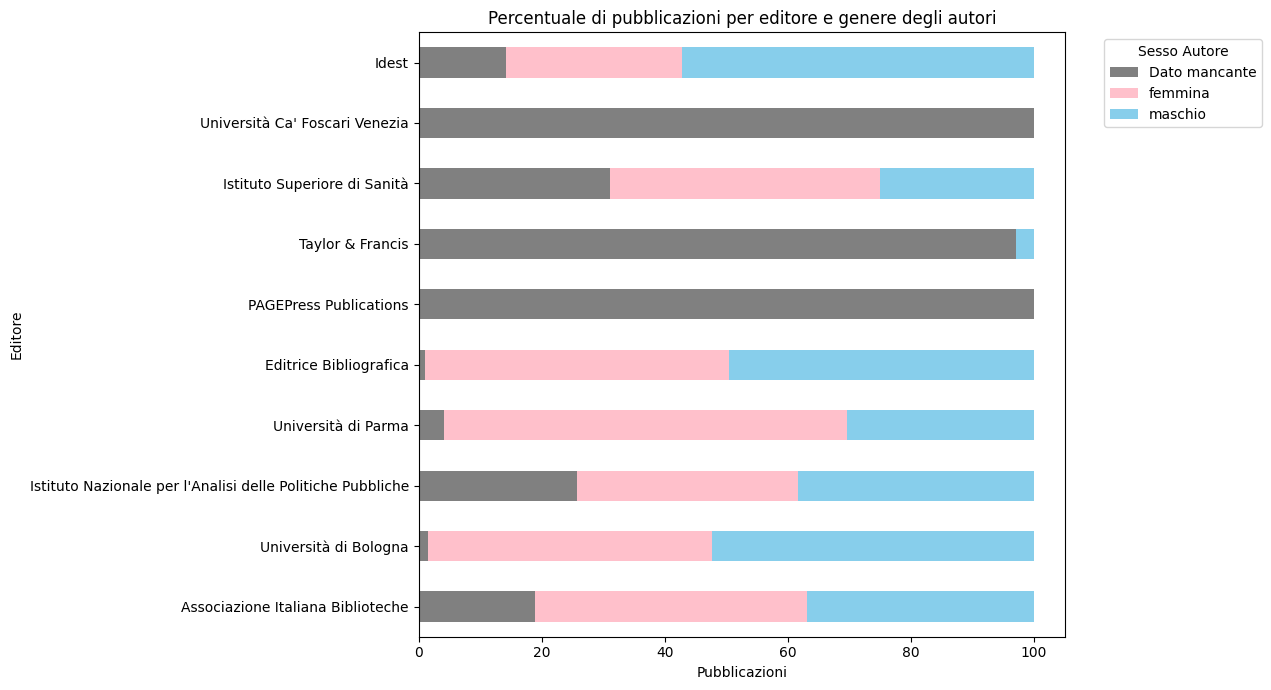

In [204]:
tabella_percentuali.loc[top_10_editori].plot.barh(
    stacked=True,
    color=mappa_colori,
    title="Percentuale di pubblicazioni per editore e genere degli autori",
    figsize=(13, 7)
)


plt.xlabel("Pubblicazioni")
plt.ylabel("Editore")
plt.legend(title="Sesso Autore", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Come mostravano già dalle prime analisi, il dato nullo influenza fortemente le statistiche.

Alcuni editori come **Università di Bologna** e **Editrice Bibliografica** hanno un dato nullo relativamente basso, per cui si può affermare che c'è una distribuzione abbastanza omogenea fra i due sessi.

Altri casi come **Associazione Italiana Biblioteche**, **Idest** e **Istituto Nazionale per l'Analisi delle Politiche Pubbliche** hanno un dato nullo tale per cui potrebbe completamente cambiare i risultati finali sulla presenza di genere.

Nel caso dell'**Università Ca' Foscari Venezia** e **PAGEPress Publications** il dato è completamente assente, o poco presente (**Taylor & Francis**).

Verifichiamo rapidamente che non ti tratti di un errore durante la pulizia dei dati, visualizzando i tre editori interessati nel dataset originario.

In [205]:
condizione_editore = (df['editori'] == "Università Ca' Foscari Venezia") | (df['editori'] == "Taylor & Francis") | (df['editori'] == "PAGEPress Publications")
df_filtrato = df.loc[condizione_editore, ['editori', 'autori']]

display(df_filtrato)

,editori,autori
582,Taylor & Francis,NaN
583,Taylor & Francis,NaN
584,Taylor & Francis,NaN
585,Taylor & Francis,NaN
586,Taylor & Francis,NaN
...,...,...
1455,Università Ca' Foscari Venezia,NaN
1456,Università Ca' Foscari Venezia,NaN
1457,Università Ca' Foscari Venezia,NaN
1458,Università Ca' Foscari Venezia,NaN


Non solo non è presente il genere dell'autore, in questi tre editori non è praticamente mai stato inserito il nome stesso dell'autore.



---



## Il Filone "Evoluzione della Ricerca"

Per rispondere a questa domanda di ricerca si andranno a creare e incrociare le colonne

- `decennio `
- `argomenti `


L'intento è individuare se ci sono dei temi che sono scomparsi o diminuiti nel tempo, e se ci sono dei nuovi temi che sono emersi recentemente, come ad esempio le tematiche di digitalizzazione.

Creiamo il df che servirà per il second grafico.

In [206]:
df_2a = df_finale.copy()

Creiamo `df_decenni` dove consideriamo solo l'anno della colonna `pubblicazione_prima`, in modo tale da poter raggruppare le pubblicazioni per decenni nella nuova colonna `decennio`.

In [207]:
df_decenni = df_2a.dropna(subset=['pubblicazione_prima']).copy()

df_decenni['decennio'] = (df_decenni['pubblicazione_prima'] // 10 * 10).astype(int)

Non andremmo a ignorare i dati nulli, che come abbiamo visto nel caso precedente possono influenzare molto l'esito dei risultati.

In [208]:
df_exploded = df_decenni.copy()
df_exploded['argomenti_puliti'] = df_exploded['argomenti'].fillna('Dato mancante')

Prepariamo il testo per l'analisi attraverso `.explode()` (in alcuni casi c'è più di un argomento per pubblicazione), eliminando eventuali maiuscole e splittiamo il testo in una lista di stringhe.

In [209]:
df_exploded['argomento_singolo'] = (
    df_exploded['argomenti_puliti']
    .astype(str)
    .str.lower()
    .str.split(';')
)

Ora esplodiamo la colonna in modo da trasformare ogni elemento della lista in un singolo record ed eliminiamo i possibili spazi rimasti vuoti con `.strip()`.

In [210]:
df_exploded = df_exploded.explode('argomento_singolo')
df_exploded['argomento_singolo'] = df_exploded['argomento_singolo'].str.strip()

Per ottene un grafico leggibile, anche in questo caso, prenderemmo un campione di 5 argomenti.

In [211]:
top_5_argomenti = df_exploded['argomento_singolo'].value_counts().head(5).index
df_top_exploded = df_exploded[df_exploded['argomento_singolo'].isin(top_5_argomenti)]

Per verificare che tutto sia andato correttamente, prima di creare il grafico visualizziamo la corrispettiva tabella.

In [212]:
tabella_2a_exploded = pd.crosstab(
    df_top_exploded['decennio'],
    df_top_exploded['argomento_singolo']
)

display(tabella_2a_exploded)

argomento_singolo,bibliografia,biblioteca,bibliotecario,dato mancante,storia della biblioteca
decennio,,,,,
1880,0,0,0,2,0
1900,0,0,0,1,0
1930,0,0,0,1,0
1950,0,0,0,8,0
1960,0,0,0,8,0
1970,2,2,3,6,0
1980,11,33,13,12,0
1990,24,9,63,38,0
2000,9,13,30,18,0


Anche in questo caso possiamo subito notare che andando avanti negli anni il dato nullo è molto significativo.

Generiamo il grafico a linee.

<Figure size 1000x600 with 0 Axes>

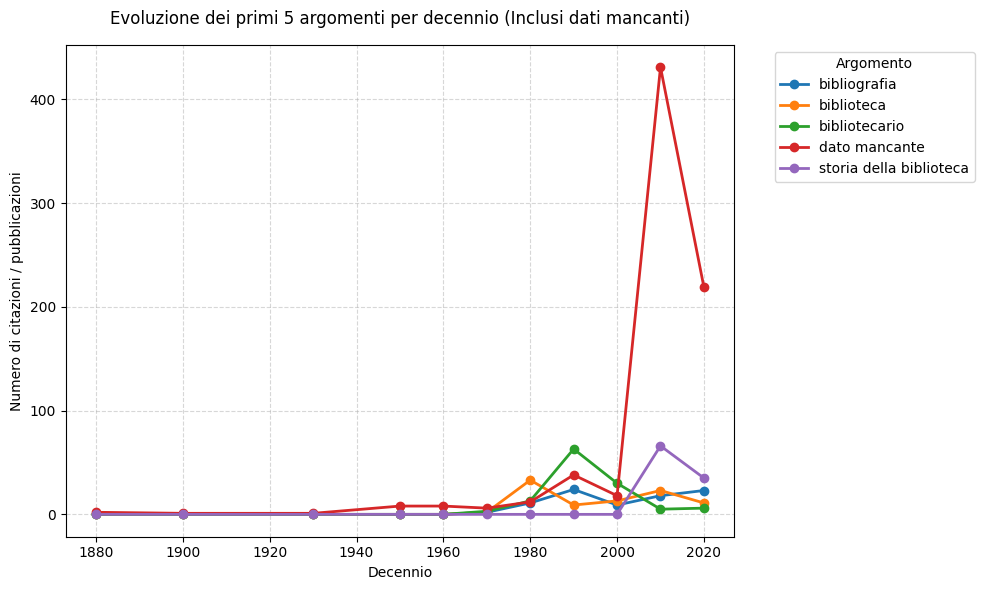

In [213]:
plt.figure(figsize=(10, 6))
tabella_2a_exploded.plot(kind='line', marker='o', linewidth=2, figsize=(10, 6))

plt.title("Evoluzione dei primi 5 argomenti per decennio (Inclusi dati mancanti)", fontsize=12, pad=15)
plt.xlabel("Decennio", fontsize=10)
plt.ylabel("Numero di citazioni / pubblicazioni", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Argomento", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Si tratta anche di un dato molto interessante, anche perchè, nonstante non sia un dato necessariamente correlato, dalle statistiche era emerso un aumento delle pubblicazioni circa nello stesso periodo.

<Axes: title={'center': 'Crescita delle pubblicazioni'}, xlabel='pubblicazione_prima'>

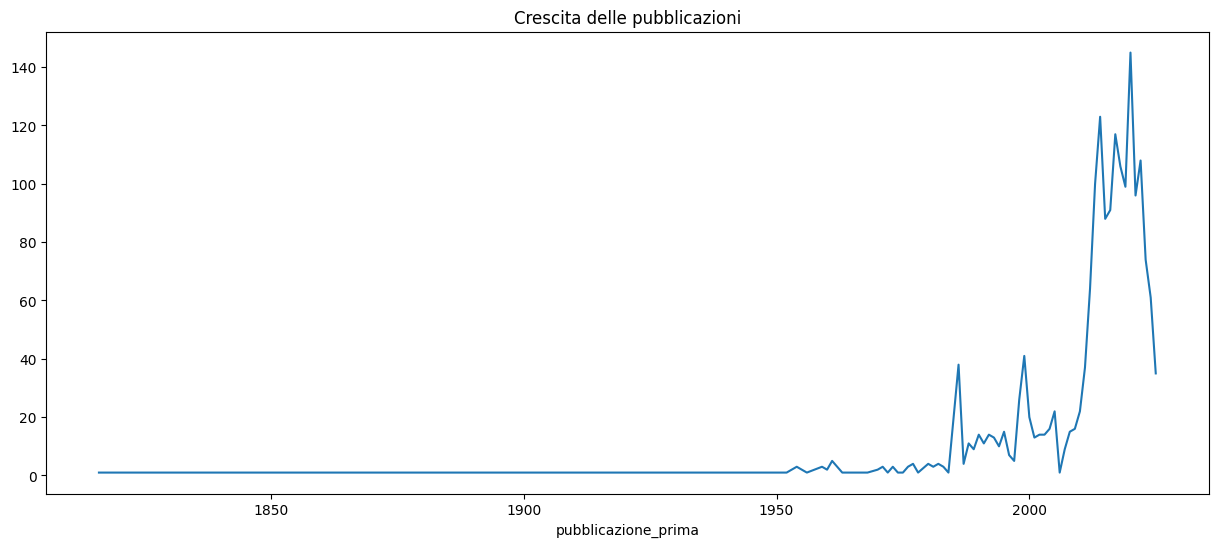

In [214]:
df_finale['pubblicazione_prima'].value_counts().sort_index().plot.line(
    title="Crescita delle pubblicazioni",
    figsize=(15,6))



In generale si può affermare che successivamente agli anni 2000 c'è stato un picco di interesse verso la **storia della biblioteca**, ma è seguito un calo, dove l'unico argomento che continua fino al 2020 ad avere un trend visibilmente in salita è la **bibliografia**.



---



Nonostante la grande presenza di dati nulli, vorrei comunque procedere ad un'analisi più precisa, andando a escludere momentaneamente i dati mancanti, e mettere a confronto le opere di cui conosciamo

- `autore` e il `genere`
- evoluzione negli anni `decenni`.


Dunque la domanda di ricerca in questo caso sarà più precisa: "Tra le opere di cui conosciamo l'autore, com'è cambiata la percentuale di autrici donne fino al 2020?".

In [215]:
import matplotlib.pyplot as plt


Per svolgere questa analisi terremo in considerazione solo i record che hanno sia l'**anno** sia il **sesso** dell'autore.

In [216]:
df_2b_valido = df_decenni.dropna(subset=['pubblicazione_prima', 'autore_sesso']).copy()


Calcoliamo le percentuali dei dati noti.

In [217]:
tabella_2b_pulita = (pd.crosstab(
    df_2b_valido['decennio'],
    df_2b_valido['autore_sesso'],
    normalize='index'
) * 100).round(1)

display(tabella_2b_pulita)

autore_sesso,femmina,maschio
decennio,,
1810,0.0,100.0
1820,0.0,100.0
1860,0.0,100.0
1880,0.0,100.0
1900,0.0,100.0
1930,0.0,100.0
1950,0.0,100.0
1960,25.0,75.0
1970,16.7,83.3


Diversamente da come avevamo visto nella prima domanda dove la percentuale di genere rispetto ai singoli editori era abbastanza omogenea, in senso assoluto per decennio, la percentuale di donne è più bassa rispetto a quella degli uomini, in particolar modo precedentemente al 2000.

Un altro dato interessante è che questa presenza femminile venga registrata solo a partire dagli anni '60.

Visualizziamo queste informazioni tramite grafico:

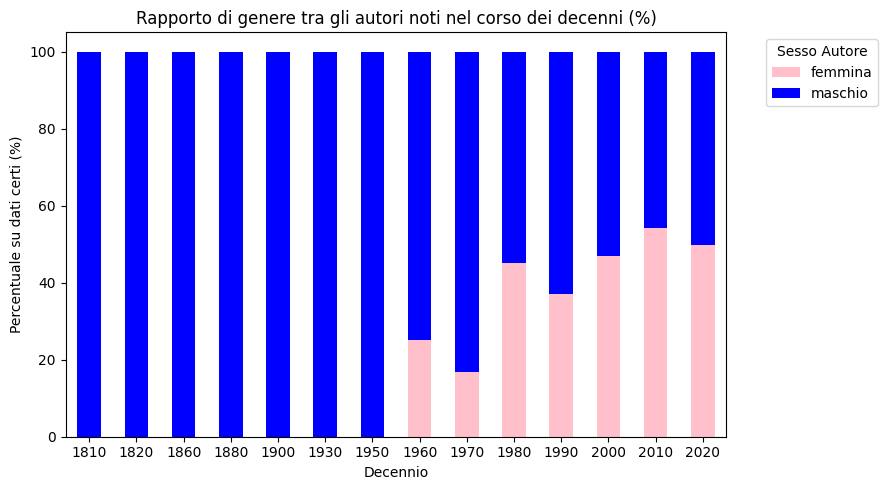

In [218]:
mappa_colori = {'femmina': 'pink', 'maschio': 'blue'}

tabella_2b_pulita.plot(
    kind='bar',
    stacked=True,
    color=mappa_colori,
    figsize=(9, 5)
)

plt.title("Rapporto di genere tra gli autori noti nel corso dei decenni (%)")
plt.xlabel("Decennio")
plt.ylabel("Percentuale su dati certi (%)")
plt.legend(title="Sesso Autore", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Questa alterazione potrebbe essere dovuta a diversi fattori:

- se nei libri senza anno di pubblicazione ci fosse un alta percentuale femminile, scartarli porterebbe di conseguenza anche all'abbassamento delle percentuali di autrici donna.

- il dato potrebbe essere influenzato a causa di schede di catalogo che erano particolarmente dettagliate quando effettuate in cartaceo (indispensabili per la gestione di archivi e biblioteche), mentre ora con pubblicazioni e cataloghi digitali spesso le importazioni massive di dati causano la loro stessa perdita. Questo tra l'altro spiegherebbe anche l'aumento significativo di dati nulli visto nel grafico tema/decenni successivamente al 2000.

- un'altra possibilità potrebbe essere dovuta alla scelta degli editori, che sopratutto se hanno pubblicazioni recenti, potrebbero avere delle percentuali più bilanciate.

Verifichiamo se c'erano molte pubblicazioni con date nulle.

In [219]:
df_finale.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1790 entries, 0 to 1791
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        1790 non-null   object
 1   titolo                    1790 non-null   object
 2   autori                    1375 non-null   object
 3   argomenti                 1042 non-null   object
 4   basi_dati                 1248 non-null   object
 5   doi_disponibili           914 non-null    object
 6   editori                   1587 non-null   object
 7   licenze_rivista           1474 non-null   object
 8   rivista                   1581 non-null   object
 9   edizione                  1375 non-null   object
 10  volume_info               1519 non-null   object
 11  pagine_info               1120 non-null   object
 12  url_disponibili           1343 non-null   object
 13  pubblicazione_prima       1784 non-null   Int64 
 14  pubblicazione_successive  3 n

No, ci sono 1786 record validi per quanto riguarda la dati di pubblicazione, anche se fossero tutte autrici non altererebbe in maniera così significativa le percentuali.

Verifichiamo la distribuzione delle pubblicazioni dei dieci editori che erano stati ultilizzati l'analisi del genere negli anni.

Riutilizzando `df_top_editori` e `decennio` definiti precedentemente, utilizziamo `.crosstab()` per visualizzare i valori percentuali.

In [220]:
crosstab_percentuale = (
    pd.crosstab(
        df_top_editori['editori'],
        df_decenni['decennio'],
        normalize='index',
    )
    * 100
).round(1)

print('\n=== 2. DISTRIBUZIONE PERCENTUALE (%) DELLA PRODUZIONE PER EDITORE ===')
display(crosstab_percentuale)


=== 2. DISTRIBUZIONE PERCENTUALE (%) DELLA PRODUZIONE PER EDITORE ===


decennio,1900,1950,1960,1970,1980,1990,2000,2010,2020
editori,,,,,,,,,
Associazione Italiana Biblioteche,0.0,0.0,0.0,0.0,2.5,16.6,6.9,41.5,32.5
Editrice Bibliografica,0.0,0.0,0.0,0.0,0.0,0.0,0.0,89.7,10.3
Idest,0.0,0.0,0.0,0.0,0.0,61.5,38.5,0.0,0.0
Istituto Nazionale per l'Analisi delle Politiche Pubbliche,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.9,77.1
Istituto Superiore di Sanità,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0
PAGEPress Publications,0.0,2.8,0.0,0.0,0.0,0.0,33.3,55.6,8.3
Taylor & Francis,2.9,8.8,5.9,29.4,29.4,14.7,0.0,8.8,0.0
Università Ca' Foscari Venezia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0
Università di Bologna,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51.8,48.2


Effettivamente alcuni editori, come ad esempio l'Unversità di Parma, che aveva una percentuale prevalentemente femminile, o l'Università di Bologna che presentava dei dati abbastanza omogenei, hanno una maggior percentuale di pubblicazioni in questi ultimi decenni, mentre Idest ed altre a percentuale prevalentemente maschile, hanno una distribuzione maggiore prima degli anni 2000.

## Il Filone "Open Access & Politiche Editoriali":

Per rispondere a questa domanda di ricerca si andranno a creare e incrociare le colonne

- `rivista `
- `licenze_rivista `

L'intento è di mappare il grado di apertura e trasparenza delle diverse case editrici.

In [221]:
import matplotlib.pyplot as plt

Creiamo un DataFrame di lavoro pulito.

In [222]:
df_3a = df_finale.copy()

Cominciamo con la pulizia della colonna `licenze`: sostituiamo i valori nulli **NaN** con la stringa *"dato mancante"* e formattiamo tutto in minuscolo.

In [223]:
df_3a['licenze_rivista'] = df_3a['licenze_rivista'].fillna('dato mancante')

df_3a['licenze_rivista'] = df_3a['licenze_rivista'].str.lower()

Verifichiamo i record prima di procedere.

In [224]:
# Verifica

print("--- Licenze originali (con NaN sostituiti) ---")
print(df_3a['licenze_rivista'].value_counts())

--- Licenze originali (con NaN sostituiti) ---
licenze_rivista
creative commons attribution-noncommercial-noderivatives                                                                                                        540
creative commons attribution-sharealike; creative commons attribution-noncommercial-noderivatives; creative commons attribution-sharealike 4.0 international    357
creative commons attribution                                                                                                                                    343
dato mancante                                                                                                                                                   316
creative commons attribution; creative commons attribution-noncommercial-sharealike                                                                             175
creative commons attribution 3.0 unported                                                                            

Ci sono due punti principali che andranno affrontati per ripulire questa colonna:
- alcuni record hanno più di un valore al loro interno, quindi procederemo andando a separarli in corrispondenza del punto e virgola, ed eliminando eventuali spazi rimanenti.

- si tratta di stringhe di testo particolarmente lunghe, poco leggibili in un grafico. Per renderle meglio visualizzabili si associeranno alle loro sigle tramite dizionario.

Procediamo separando le stringhe in corrispondenza della punteggiatura tramite `.split()` e li rendiamo valori separati tramite `.explode()`.

In [225]:
df_3a['licenze_rivista'] = df_3a['licenze_rivista'].str.split(r';\s*')


Esplodiamo la colonna in modo tale che per ogni riga ci cia una licenza.

In [226]:
df_3a = df_3a.explode('licenze_rivista')


Creiamo il dizionario in cui associamo ad ogni licenza la sua sigla ufficiale per semplificare la lettura del grafico.

In [227]:
dizionario_licenze = {
    'creative commons attribution-noncommercial-noderivatives': 'CC BY-NC-ND',
    'creative commons attribution': 'CC BY',
    'creative commons attribution-sharealike': 'CC BY-SA',
    'creative commons attribution-noncommercial-sharealike': 'CC BY-NC-SA',
    'creative commons attribution 3.0 unported': 'CC BY 3.0',
    'creative commons attribution 4.0 international': 'CC BY 4.0',
    'creative commons attribution-sharealike 4.0 international': 'CC BY-SA 4.0',
    'dato mancante': 'Dato Mancante'
}

Rimuoviamo eventuali spazi vuoti accidentali tramite `.strip()` ai lati delle parole e applichiamo il dizionario.


In [228]:
df_3a['licenze_rivista'] = df_3a['licenze_rivista'].str.strip()
df_3a['licenze_rivista'] = df_3a['licenze_rivista'].replace(dizionario_licenze)

Per verificare che tutto sia andato correttamente stampiamo la lista dei nuovi valori.

In [229]:
# Verifica
print("\n--- Licenze pulite ed esplose (con sigle) ---")
print(df_3a['licenze_rivista'].value_counts())


--- Licenze pulite ed esplose (con sigle) ---
licenze_rivista
CC BY-NC-ND      897
CC BY            518
CC BY-SA         358
CC BY-SA 4.0     357
Dato Mancante    316
CC BY-NC-SA      175
CC BY 3.0         57
CC BY 4.0          1
Name: count, dtype: int64


Ora con lo stesso metodo ripuliamo la colonna `rivista`:

- sostituiamo il dato mancante con *"dato mancante"*,
- rendiamo tutti i caratteri in minuscolo con `.lower()` ed elimiamo eventiali spazi vuoti con `.strip()`.

In [230]:
df_3a['rivista'] = df_3a['rivista'].fillna('dato mancante')
df_3a['rivista'] = df_3a['rivista'].str.lower().str.strip()

Come nelle analisi precedenti prenderemo un campione di dieci riviste da inserire nel nostro Dataframe di lavoro  e sul quale applicare il `.crosstab()`.

In [231]:
top_10_riviste = df_3a['rivista'].value_counts().head(10).index

df_top10 = df_3a[df_3a['rivista'].isin(top_10_riviste)]

Creiamo la tabella:

In [232]:
tabella_incrociata = pd.crosstab(
    df_top10['rivista'],
    df_top10['licenze_rivista'],
)


print("\n--- Tabella Incrociata (Top 10 Riviste x Licenze) ---")
display(tabella_incrociata)


--- Tabella Incrociata (Top 10 Riviste x Licenze) ---


licenze_rivista,CC BY,CC BY 3.0,CC BY 4.0,CC BY-NC-ND,CC BY-NC-SA,CC BY-SA,CC BY-SA 4.0,Dato Mancante
rivista,,,,,,,,
aib studi,0,0,0,357,0,357,357,0
annali dell'istituto superiore di sanità,0,0,0,32,0,0,0,0
bibelot,135,0,0,0,0,0,0,0
biblioteche oggi trends,0,0,0,0,0,0,0,97
bibliothecae.it,0,0,0,337,0,0,0,0
dato mancante,35,0,1,168,0,1,0,4
fragmenta entomologica,34,0,0,0,0,0,0,0
onychium (rivista),124,0,0,0,0,0,0,0
sinappsi. connessioni tra ricerca e politiche pubbliche,175,0,0,0,175,0,0,0


Si può notare che in questo caso il dato nullo (esclusa **iblioteche oggi trends**) le riviste hanno un dato nullo molto basso, e anche tra le pubblicazioni che non presentano un titolo di rivista, comunque ci sono poche licenze nulle.


C'è una divisone particolare tra le riviste **aib studi**, essento tutte e tre le licenze pari a 357

In [233]:
conteggio_aib = (df_3a['rivista'].str.lower() == 'aib studi').sum()

print(f"Numero di pubblicazioni per la rivista 'aib': {conteggio_aib}")

Numero di pubblicazioni per la rivista 'aib': 1071


La somma torna.


Creiamo il grafico

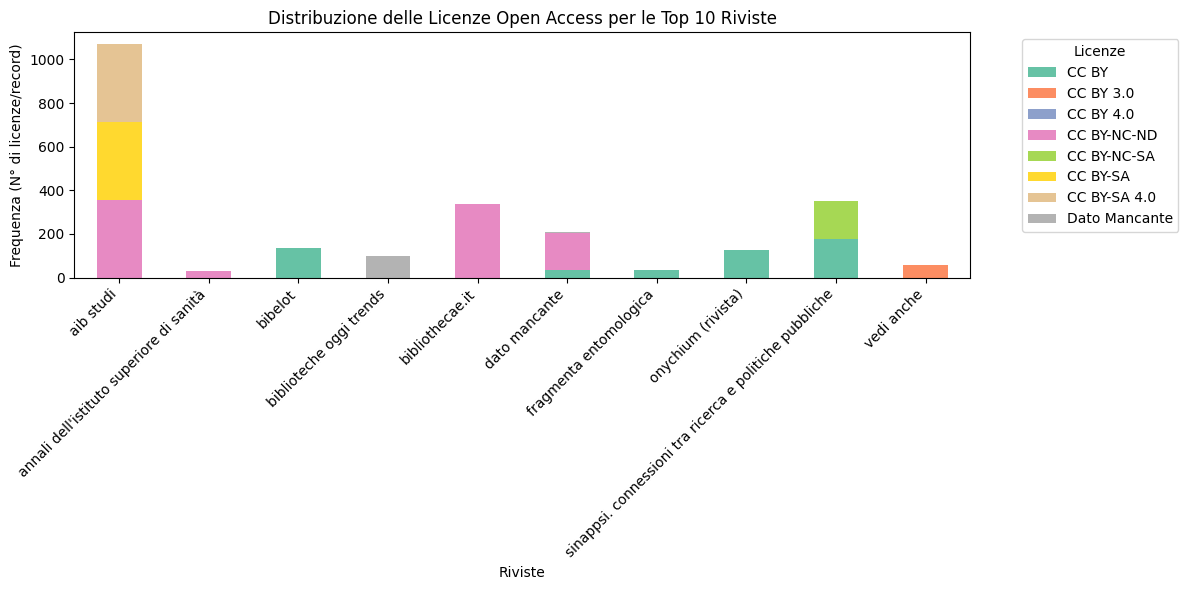

In [234]:
tabella_incrociata.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='Set2'
  )

plt.title('Distribuzione delle Licenze Open Access per le Top 10 Riviste')
plt.xlabel('Riviste')
plt.ylabel('Frequenza (N° di licenze/record)')

plt.xticks(rotation=45, ha='right')

plt.legend(title='Licenze', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

I dati evidenziano una spiccata omogeneità interna a ciascuna testata, a dimostrazione del fatto che le politiche di licensing sono definite a livello editoriale e non lasciate alla discrezionalità dei singoli autori.

Emerge una chiara polarizzazione: mentre le riviste specialistiche prediligono la licenza liberale CC BY per massimizzare la diffusione della ricerca, le testate istituzionali e associative adottano prevalentemente clausole protettive (CC BY-NC-ND e CC BY-SA) per tutelare la proprietà intellettuale e impedire lo sfruttamento commerciale dei contributi.



---



## Conclusioni

## Domanda 1.A

**Analisi del Genere degli Autori per Casa Editrice**



---


Il primo interrogativo di ricerca intendeva verificare se la presenza di autrici donne e autori uomini fosse omogenea all'interno del panorama editoriale analizzato o se, al contrario, emergessero marcate preferenze o segregazioni di genere tra le singole case editrici.

L'analisi condotta sui primi 10 editori per volume di pubblicazioni — calcolata in percentuale normalizzata e comprensiva della quota di record privi di indicazione (Dato mancante) — restituisce un quadro articolato:

*  l'inclusione dei **dati mancanti** ha permesso di evidenziare una differente qualità della catalogazione tra gli editori. Mentre alcune realtà editoriali presentano una copertura quasi totale delle informazioni relative agli autori, altre mostrano una percentuale non trascurabile di dati non pervenuti (es. Università Ca' Foscari Venezia e PAGEPress Publications con la completa assenza di dati), elemento che suggerisce una diversa attenzione alla tracciabilità dei dati biografici.

* al netto delle lacune informative, non si osserva un monopolio maschile generalizzato, bensì una sostanziale eguaglianza di presenza complessiva, con significative variazioni a seconda dell'editore. In particolare:
si evidenziano delle realtà a spiccata prevalenza femminile (es. Università di Parma, dove anche ignorando i dati nulli comunque si afferma una forte presenza femminile), e contestualmente, si notano case editrici in cui la presenza maschile rimane maggioritaria (es. Idest, con il 60% di autori maschi).

In sintesi i dati confermano che la rappresentanza di genere è distribuita in modo abbastanza uniforme, ma la forte presenza in alcuni casi di dati nulli potrebbe pesantemente rovesciare queste percentulai (nel caso di Idest e Associazione Italiana Biblioteche c'è quasi un 20% di dati nulli che cambierebbe completamente la statistica se fosse a maggioranza maschile o femminile).



---



##Domanda 2.A e 2.B

**Evoluzione dei Temi e degli Argomenti nel Corso dei Decenni**


---


L'analisi dell'evoluzione temporale dei principali argomenti trattati nelle pubblicazioni consente di tracciare l'evoluzione dell'interesse scientifico e professionale nell'ambito biblioteconomico, mettendo in luce la transizione dei filoni di ricerca nel corso del tempo.
Dall'osservazione del grafico emergono alcuni elementi di particolare rilievo:

* sotto il profilo metodologico, è subito evidente come negli ultimi vent'anni (nel periodo compreso tra i decenni 2000 e 2020) si registri un picco significativo riguardante i **dati nulli**.

Questo fenomeno, tutt'altro che trascurabile, suggerisce una potenziale disomogeneità nella catalogazione dei volumi più recenti o una transizione nei sistemi di indicizzazione che ha temporaneamente ridotto la completezza informativa dei metadati, forse anche influenzato da una maggiore frequenza di pubblicazione avvenuta negli stessi anni.

* Per quanto riguarda i contenuti scientifici, successivamente agli anni 2000 si rileva un interesse attorno alla **storia della biblioteca**, testimonianza di una stagione di vivace riflessione sull'identità e sul ruolo storico delle istituzioni conservative, probabilmente anche in risposta alle nuove realtà di biblioteca digitale e dei nuovi media. A questo culmine è tuttavia seguito un progressivo calo negli ultimi anni, indicando forse un ridimensionamento di questo filone all'interno del dibattito generale.

* Il tema della **Bibliografia**, seppure con alti e bassi, è l'unico ambito che mostra un trend visibilmente stabile. Questo dato sottolinea la persistente centralità di questa disciplina che ha  mantenuto la propria rilevanza anche nell'era digitale, probabilmente spinta dalle nuove esigenze di reperimento, organizzazione e catalogazione delle risorse informative.

**La presenza di Genere nel tempo**

Per approfondire ulteriormente la ricerca è stato analizzato come la **presenza di genere** si sia evoluta all'interno delle pubblicazioni, andando momentaneamente ad escludere i dati nulli.

È interessante notare come l'inclusione o l'esclusione dei record incompleti modifichi la distribuzione di genere rilevata. Se sull'intero corpus e l'analisi specifica su alcuni editori, si osservava una leggera prevalenza complessiva di autrici donne, l'analisi ristretta ai soli record - dotati sia di datazione che di indicazione del sesso - mostra una prevalenza maschile costante nei decenni.

Per comprendere meglio questa informazione si è deciso di analizzare le pubblicazioni effettuate da quegli editori che erano stati selezionati a campione: effettivamente è emerso che le percentuali a maggioranza femminile o che comunque presentavano un buon equilibrio fra i due generi, erano più recenti - in particolare concentrate dopo gli anni 2000 - rispetto a quelle che avevano mostrato una percentuale prevalentemente maschile.

In generale si può affermare che si può notare un trend che vira verso un **parità di genere** nell'ambito delle pubblicazioni all'interno di questo dataset.



---



## Domanda 3.1

**L'adozione delle licenze Creative Commons tra le principali testate**


---



L'analisi incrociata tra le prime dieci riviste per volume di pubblicazioni e le licenze di riutilizzo rileva una marcata standardizzazione interna a ciascuna testata. Gli editori non lasciano la scelta della licenza ai singoli autori, ma applicano politiche editoriali a livello di rivista.

Nel corpus si evidenziano due differenti filosofie di gestione dell'Open Access:

* da un lato, testate come **Bibelot**, **Fragmenta Entomologica** e **Onychium** adottano la licenza `CC BY` nella sua forma più pura, favorendo la massima circolazione e il riutilizzo della ricerca;

* dall'altro, riviste istituzionali e accademiche come **AIB Studi**, **Bibliothecae.it** e gli **Annali dell'Istituto Superiore di Sanità** prediligono clausole di salvaguardia più restrittive (in particolare CC BY-NC-ND e CC BY-NC-SA), volte a impedire lo sfruttamento commerciale da parte di terzi e a preservare l'integrità del testo.

## Codice utile

Qui vi lascio pezzi di codice completi o semi-completi da utilizzare, di cui vi ho parlato durante le lezioni.

Vi consiglio **caldamente** di dare un occhio anche alla documentazione ufficiale di Python e Pandas, e a chiedere spiegazioni a un'AI se avete dubbi o se trovate un ostacolo che non riuscite a superare.

* [Chatbot dedicato al corso](https://www.google.com/url?q=https%3A%2F%2Fgemini.google.com%2Fgem%2F1jP2JvydYTq9pm7JiZLFcCowTliR2gBaD%3Fusp%3Dsharing)
* [Documentazione Python](https://docs.python.org/3/)
* [Documentazione Pandas](https://pandas.pydata.org/docs/user_guide/index.html#user-guide)

Non partite subito col botto. Prendetevi tempo a esplorare i dati, capire se ci sono problemi, capire cosa vi interessa, e nel frattempo provate a maturare domande possibili a cui rispondere con l'analisi.

In [235]:
# Definiamo come vogliamo riempire i vuoti per ciascuna colonna testuale

valori_riempimento = {
    'autori': 'Sconosciuto',
    'argomenti': 'Non specificato',
    'basi_dati': 'Non specificato',
    'doi_disponibili': 'Non disponibile',
    'editori': 'Editore sconosciuto',
    'licenze_rivista': 'Non specificata',
    'rivista': 'Rivista sconosciuta',
    'edizione': 'Non specificata',
    'volume': 'Non specificato',
    'pagine': 'Non specificate',
    'url_disponibili': 'Non disponibile'
}

# Applichiamo la sostituzione su tutto il DataFrame

df_clean = df_clean.fillna(value=valori_riempimento)

In [236]:
# df.COLONNA OPPURE
# df["COLONNA"]

In [237]:
# df["NUOVA_COLONNA"] = ...

In [238]:
# df.COLONNA[INDICE] OPPURE
# df["COLONNA"][INDICE]

In [239]:
# df.COLONNA[INIZIO:FINE] OPPURE
# df["COLONNA"][INIZIO:FINE]

In [240]:
# df.COLONNA.str.split("SEPARATORE") OPPURE
# df["COLONNA"].str.split("SEPARATORE")

In [241]:
# df.COLONNA.str.replace("VALORE_DA_SOSTITUIRE", "VALORE_SOSTITUENTE") OPPURE
# df["COLONNA"].str.replace("VALORE_DA_SOSTITUIRE", "VALORE_SOSTITUENTE")

In [242]:
# df["COLONNA"] = df["COLONNA"].astype("TIPO") OPPURE
# df["COLONNA"] = df["COLONNA"].astype(TIPO)

In [243]:
# df.COLONNA.value_counts()
# df["COLONNA"].value_counts()

In [244]:
# df.COLONNA.unique()

In [245]:
# df.iloc[INDICE]

In [246]:
# df.iloc[INIZIO:FINE]

In [247]:
# df[df["COLONNA"] CONDIZIONE] OPPURE
# df.loc[df["COLONNA"] CONDIZIONE]

In [248]:
# df.loc[(df["COLONNA"] CONDIZIONE) & (df["ALTRA_COLONNA"] ALTRA_CONDIZIONE)]
# es. df.loc[df["Sex"] == "female"]

In [249]:
# df.loc[(df["COLONNA"] CONDIZIONE) | (df["ALTRA_COLONNA"] ALTRA_CONDIZIONE)]

In [250]:
# df.loc[INDICE, "COLONNA"] = VALORE_CHE_SOSTITUISCE

In [251]:
'''

for INDICE, RIGA in df.iterrows():
  ...

'''

'\n\nfor INDICE, RIGA in df.iterrows():\n  ...\n\n'

In [252]:
# df.filter(["COLONNA", "ALTRA_COLONNA"])

In [253]:
# NUOVO_DF = df.filter([...]) OPPURE
# NUOVO_DF = df[[...]]

In [254]:
# .sort_index()

In [255]:
# df.sort_values(ascending=...)

# df.sort_values([])

# df["COLONNA"].sort_values(ascending=...)

In [256]:
# .explode()

In [257]:
# .drop(columns=["...", "..."])

In [258]:
# .groupby()

In [259]:
'''

def FUNZIONE(...):
  ...
  return ...

'''

'\n\ndef FUNZIONE(...):\n  ...\n  return ...\n\n'

In [260]:
# .apply(FUNZIONE)

In [261]:
# df.groupby("COLONNA")["ALTRA_COLONNA"].sum()

In [262]:
# df.groupby("COLONNA")["ALTRA_COLONNA"].mean()

In [263]:
# df.groupby("COLONNA")["ALTRA_COLONNA"].median()

In [264]:
# .fillna()

In [265]:
# df["COLONNA"].notna()

In [266]:
# df.duplicated()

# df.duplicated().value_counts()

In [267]:
'''

ax = df["COLONNA"].value_counts().plot.bar(
    color="STRINGA_RGB" OPPURE ["LISTA", "DI", "COLORI"],
    figsize=(12,6),
    rot=0
    )

ax.set_facecolor('#f0f0f0')
ax.grid(color='white', linewidth=1.5, axis='y')
ax.set_axisbelow(True)
for bordo in ax.spines.values():
    bordo.set_visible(False)
colore_testo = '#444444'
ax.set_title("TITOLO",
             loc="left",
             pad=20,
             fontsize=16,
             color=colore_testo)
ax.tick_params(colors=colore_testo, labelsize=11)
ax.xaxis.label.set_color(colore_testo)
ax.set_xlabel("NOME_ASSE_X")
ax.set_ylabel("NOME_ASSE_Y", fontsize=12, labelpad=10)

'''

'\n\nax = df["COLONNA"].value_counts().plot.bar(\n    color="STRINGA_RGB" OPPURE ["LISTA", "DI", "COLORI"],\n    figsize=(12,6),\n    rot=0\n    )\n\nax.set_facecolor(\'#f0f0f0\')\nax.grid(color=\'white\', linewidth=1.5, axis=\'y\')\nax.set_axisbelow(True)\nfor bordo in ax.spines.values():\n    bordo.set_visible(False)\ncolore_testo = \'#444444\'\nax.set_title("TITOLO",\n             loc="left",\n             pad=20,\n             fontsize=16,\n             color=colore_testo)\nax.tick_params(colors=colore_testo, labelsize=11)\nax.xaxis.label.set_color(colore_testo)\nax.set_xlabel("NOME_ASSE_X")\nax.set_ylabel("NOME_ASSE_Y", fontsize=12, labelpad=10)\n\n'

In [268]:
# .plot.line(...)

In [269]:
# .plot.pie(...)

In [270]:
# .plot.scatter(...)

In [271]:
# altri grafici: .barh(...), .hist(...), .box(...), .area(...)

In [272]:
# pd.merge(DATAFRAME_1, DATAFRAME_2, on="CHIAVE", how="inner")

## 4. Conclusione

Chiudete il discorso con delle conclusioni chiare che sintetizzano i risultati finali.

**Va benissimo non avere scoperto nulla di nuovo**. Mi interessa di più il vostro procedimento, il modo in cui ragionate.

Quando avete fatto tutto (_notebook_, GitHub, Zenodo), ricordatevi di mandarmi per mail (sebastian.barzaghi2@unibo.it) il DOI del record pubblicato su Zenodo.